# Installations

In [13]:
!pip install openai pillow numpy opencv-python jiwer

In [14]:
!pip install torch torchvision torchaudio matplotlib pandas pillow requests jiwer

### Imports

In [15]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt


from PIL import Image
from jiwer import wer, cer

### Download models and Version Check

In [16]:
from openai import OpenAI
import os

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

In [3]:
import os
#print(os.getenv("OPENAI_API_KEY"))

In [17]:
import sys
import torch

print("Python path:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)

Python path: C:\ProgramData\anaconda3\envs\openai-cloud\python.exe
Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torch CUDA: 11.8


In [18]:
prompt_text_0 = "Extract all text from this image exactly as written. Preserve line breaks."

In [19]:
prompt_text_1 = """
You are performing OCR.

Extract all visible text exactly as it appears.

Rules:
- Preserve line breaks.
- Preserve punctuation.
- Preserve capitalization.
- Do not translate.
- Do not explain.
- Do not add comments.
- Output only the transcription.
"""

In [20]:
import base64

def run_ocr_one_image(image_path, prompt_text):
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_base64 = base64.b64encode(image_bytes).decode("utf-8")

    response = client.responses.create(
        model="gpt-5.4",
        max_output_tokens=1500,
        input=[{
            "role": "user",
            "content": [
                {"type": "input_text", "text": prompt_text},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{image_base64}"
                }
            ]
        }]
    )

    return response.output_text

### English Dataset Directory

In [21]:
ENG_IMAGES_DIR = "../../English_dataset/images_eng"
ENG_GOLD_DIR = "../../English_dataset/gold_english"

In [22]:
pages = [1,2,3,4,5,6]

# Experiment 4 - With Noise and Preprocessing

In [23]:
import os

output_dir_4 = "outputs/Experiment_4"
os.makedirs(output_dir_4, exist_ok=True)

In [24]:
import os

os.makedirs("corrupted_preprocessed_images", exist_ok=True)

In [25]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v3(image):
    img = np.array(image.convert("RGB"))

    #grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #sharpening
    kernel = np.array([
        [0, -0.4, 0],
        [-0.4, 2.5, -0.4],
        [0, -0.4, 0]
    ])
    sharpened = cv2.filter2D(gray, -1, kernel)

    #balanced threshold
    _, binary = cv2.threshold(
        sharpened,
        145,
        255,
        cv2.THRESH_BINARY
    )

    return Image.fromarray(binary)

### apply preprocessed image to noisy images

In [26]:
from PIL import Image

for p in pages:

    img = Image.open(
        f"corrupted_images/{p}.jpg"
    ).convert("RGB")

    preprocessed_img = preprocess_image_v3(img)

    preprocessed_img.save(
        f"corrupted_preprocessed_images/{p}.jpg"
    )

print("Done saving corrupted + preprocessed images.")

Done saving corrupted + preprocessed images.


### Test one image

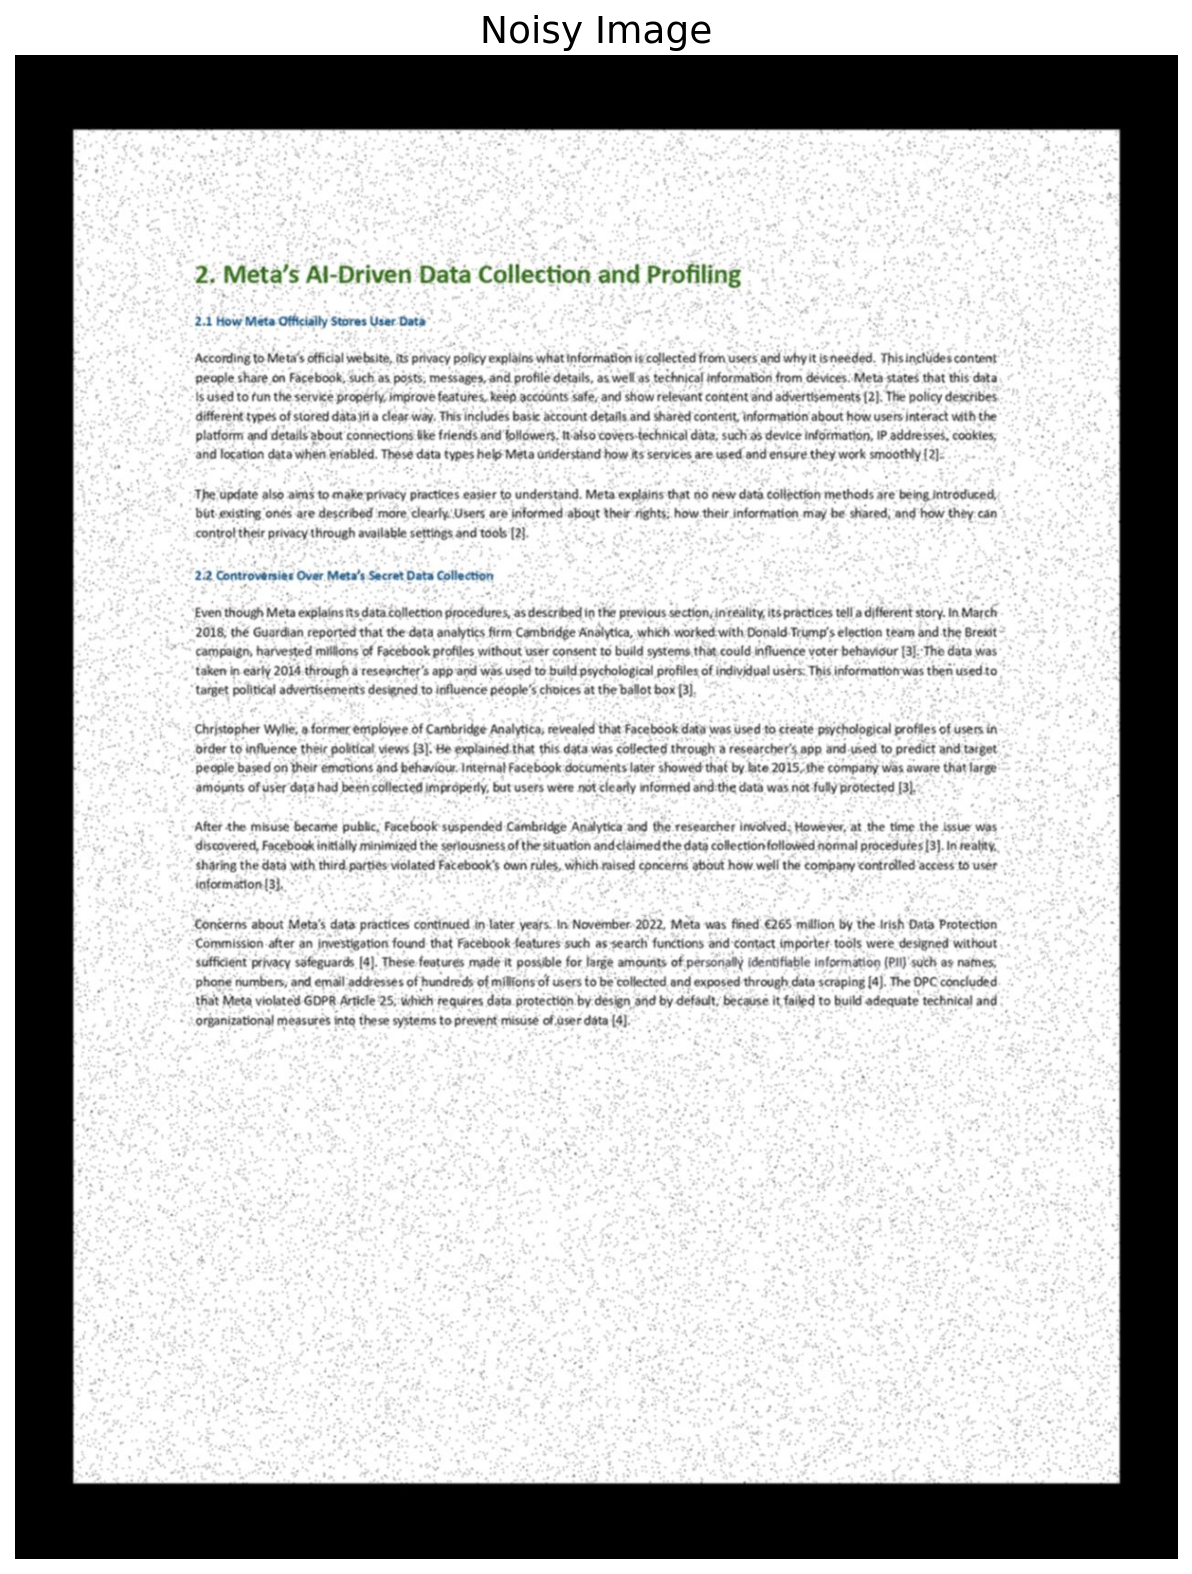

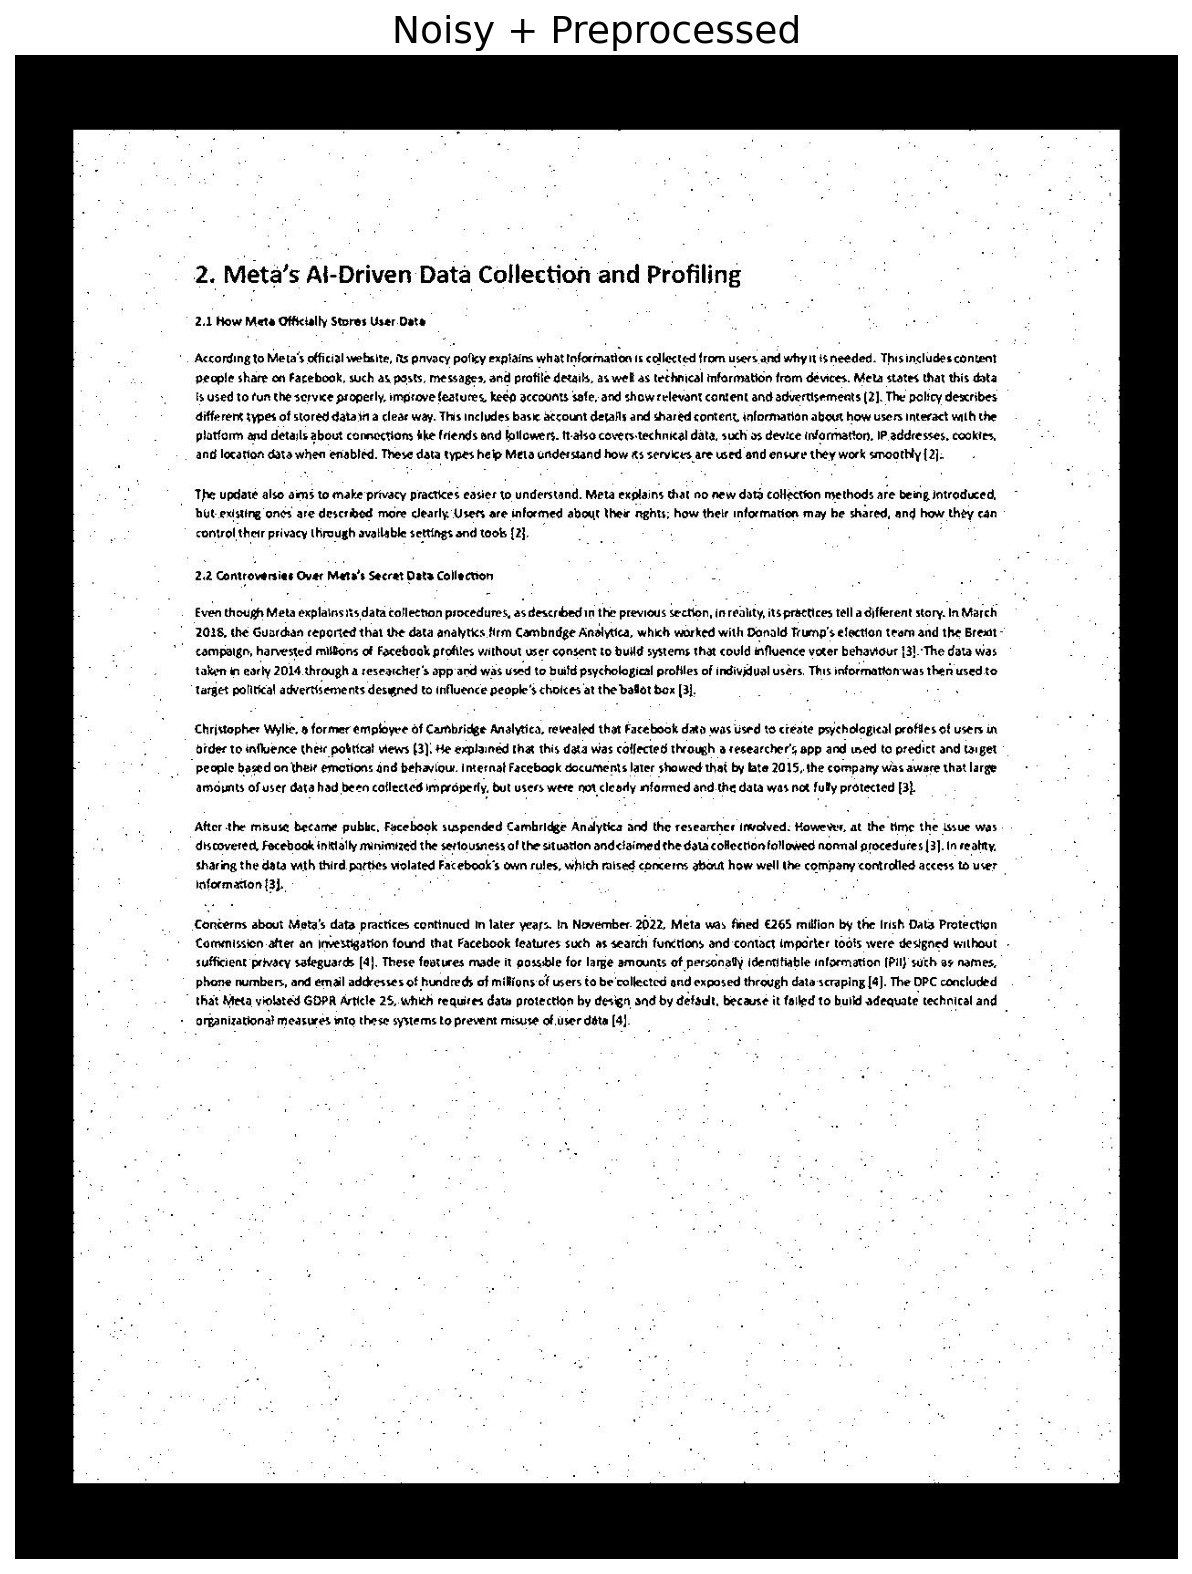

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

test_page = 2

noisy_img = Image.open(f"corrupted_images/{test_page}.jpg").convert("RGB")
preprocessed_img = Image.open(f"corrupted_preprocessed_images/{test_page}.jpg")

plt.figure(figsize=(10,14), dpi=150)
plt.imshow(noisy_img)
plt.title("Noisy Image", fontsize=18)
plt.axis("off")
plt.show()

plt.figure(figsize=(10,14), dpi=150)
plt.imshow(preprocessed_img, cmap="gray")
plt.title("Noisy + Preprocessed", fontsize=18)
plt.axis("off")
plt.show()

In [28]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(
        "corrupted_preprocessed_images",
        f"{p}.jpg"
    )

    output_path = os.path.join(
        output_dir_4,
        f"page_{p}.txt"
    )

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_0
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 1
Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics

Smart Everything

Uphill battle - Threats posed by AI to online privacy: Is there hope for
having any control over one´s online data trail, when faced by even
better AI profiling tools?

1. Introduction

Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. AI systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling pra

### Evaluation -Experiment 4

In [29]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [30]:
results_exp4 = []

for p in pages:
    print(f"Evaluating Experiment 4 - page {p}...")

    gold_path = os.path.join(
        ENG_GOLD_DIR,
        f"{p}.txt"
    )

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(
        output_dir_4,
        f"page_{p}.txt"
    )

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp4.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating Experiment 4 - page 1...
Evaluating Experiment 4 - page 2...
Evaluating Experiment 4 - page 3...
Evaluating Experiment 4 - page 4...
Evaluating Experiment 4 - page 5...
Evaluating Experiment 4 - page 6...


In [31]:
print("=== Experiment 4 Results - GPT - English ===")
df_exp4 = pd.DataFrame(results_exp4)
df_exp4

=== Experiment 4 Results - GPT - English ===


,page,WER,CER
0,1,0.005063,0.000793
1,2,0.029060,0.004970
2,3,0.017429,0.008398
3,4,0.013793,0.003383
4,5,0.020408,0.002728
5,6,0.016667,0.006321


In [32]:
mean_wer_exp4 = df_exp4["WER"].mean()
mean_cer_exp4 = df_exp4["CER"].mean()

print("=== Experiment 4 Results - GPT-English ===")
print(f"Mean WER: {mean_wer_exp4:.4f}")
print(f"Mean CER: {mean_cer_exp4:.4f}")

=== Experiment 4 Results - GPT-English ===
Mean WER: 0.0171
Mean CER: 0.0044


#### Save result

In [33]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

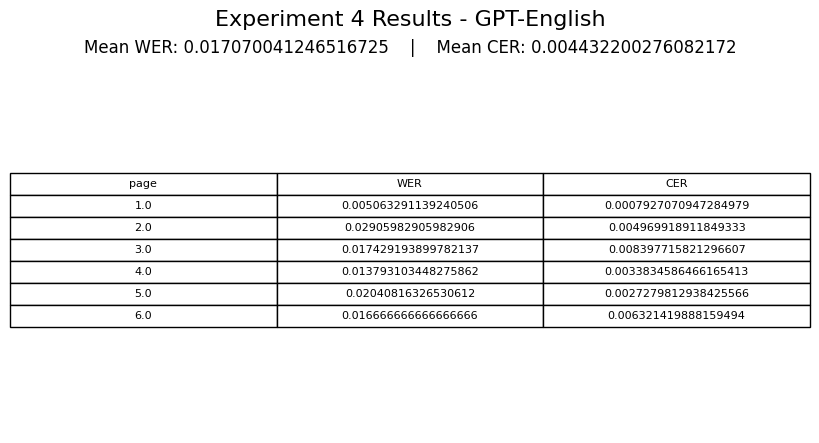

Saved: outputs/Results\experiment_4_results.png


In [34]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp4["WER"].mean()
mean_cer = df_exp4["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_4_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp4) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 4 Results - GPT-English", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)


table = ax.table(
    cellText=df_exp4.values,
    colLabels=df_exp4.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

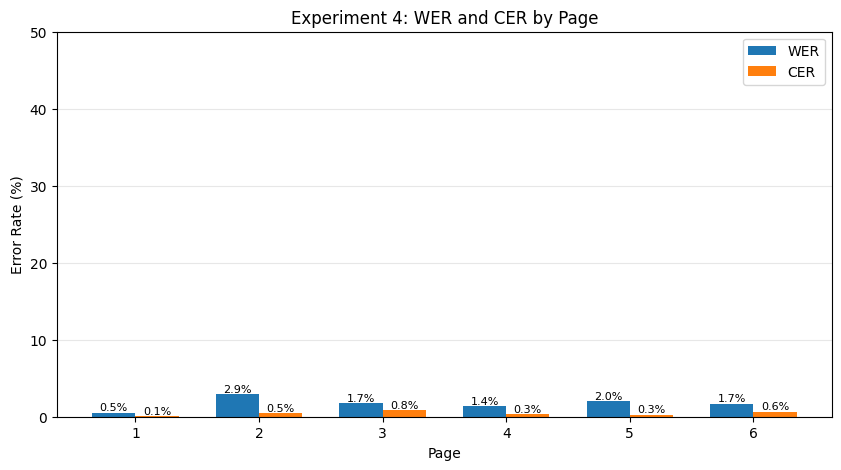

In [36]:
x = np.arange(len(df_exp4))
width = 0.35

wer_pct = df_exp4["WER"] * 100
cer_pct = df_exp4["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp4["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 4: WER and CER by Page")
plt.legend()
plt.grid(axis="y", alpha=0.3)


plt.ylim(0, 50)
plt.yticks(np.arange(0, 51, 10))

plt.show()

#### 4. Word Detection Rate

Word Detection Rate compares the number of words in the gold-standard text with the number of words produced by PyTesseract. The word detection rate shows whether the OCR system extracted too few, too many, or approximately the correct number of words.

A value close to 100% means that the OCR output contains a similar number of words as the gold standard. A value below 100% suggests that some words may have been missed, while a value above 100% may indicate extra or incorrectly split words.

In [37]:
word_detection_results = []

for p in pages:
    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")
    pred_path = os.path.join(output_dir_4, f"page_{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    gold_words = len(gold_norm.split())
    ocr_words = len(pred_norm.split())

    detection_rate = (ocr_words / gold_words) * 100 if gold_words > 0 else 0

    page_wer = df_exp4.loc[
        df_exp4["page"] == p,
        "WER"
    ].values[0]

    word_detection_results.append({
        "page": p,
        "Gold Words": gold_words,
        "OCR Words": ocr_words,
        "WER": page_wer,
        "Word Detection Rate (%)": detection_rate
    })

word_detection_df = pd.DataFrame(word_detection_results)

word_detection_df

,page,Gold Words,OCR Words,WER,Word Detection Rate (%)
0,1,395,394,0.005063,99.746835
1,2,585,585,0.029060,100.000000
2,3,459,459,0.017429,100.000000
3,4,435,434,0.013793,99.770115
4,5,392,391,0.020408,99.744898
5,6,660,659,0.016667,99.848485


##### Observations(Word Detection Rate)
Page 6 achieved a Word Detection Rate of 99.85%, indicating that almost all words were successfully detected by Tesseract. However, the WER of 10.6% shows that some detected words were recognized incorrectly. This demonstrates that a high detection rate does not necessarily imply perfect recognition accuracy, as OCR may locate words correctly while still producing transcription errors.

#### 5. OCR Speed Analysis

We will measure how long PyTesseract takes to process each page in Experiment 1. Runtime is calculated separately for every image, and then the average and total processing time are reported.This helps evaluate not only OCR accuracy, but also processing efficiency.

In [38]:
import time

ocr_speed_results = []

for p in pages:

    image_path = os.path.join(
        "corrupted_preprocessed_images",
        f"{p}.jpg"
    )

    start_time = time.time()

    output_text = run_ocr_one_image(
        image_path,
        prompt_text_0
    )

    end_time = time.time()

    elapsed_time = end_time - start_time

    ocr_speed_results.append({
        "page": p,
        "OCR Time (seconds)": elapsed_time
    })

ocr_speed_df = pd.DataFrame(ocr_speed_results)

ocr_speed_df

,page,OCR Time (seconds)
0,1,5.859255
1,2,9.678293
2,3,11.647372
3,4,8.064957
4,5,6.240612
5,6,10.060899


In [39]:
average_time = ocr_speed_df["OCR Time (seconds)"].mean()
total_time = ocr_speed_df["OCR Time (seconds)"].sum()

print(f"Average OCR time per page: {average_time:.3f} seconds")
print(f"Total OCR time for Experiment 1: {total_time:.3f} seconds")

Average OCR time per page: 8.592 seconds
Total OCR time for Experiment 1: 51.551 seconds


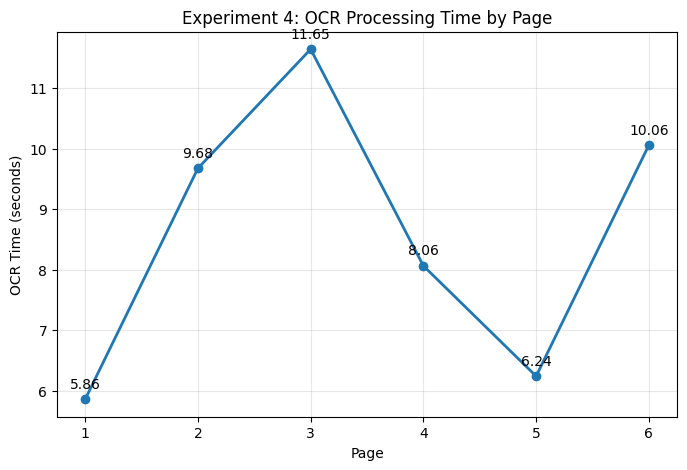

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    ocr_speed_df["page"],
    ocr_speed_df["OCR Time (seconds)"],
    marker="o",
    linewidth=2
)

for _, row in ocr_speed_df.iterrows():
    plt.annotate(
        f'{row["OCR Time (seconds)"]:.2f}',
        (
            row["page"],
            row["OCR Time (seconds)"]
        ),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Page")
plt.ylabel("OCR Time (seconds)")
plt.title("Experiment 4: OCR Processing Time by Page")

plt.xticks(ocr_speed_df["page"])
plt.grid(True, alpha=0.3)

plt.show()

In [41]:
speed_analysis_df = (
    word_detection_df[
        ["page", "WER", "Word Detection Rate (%)"]
    ]
    .merge(
        ocr_speed_df,
        on="page"
    )
)

speed_analysis_df

,page,WER,Word Detection Rate (%),OCR Time (seconds)
0,1,0.005063,99.746835,5.859255
1,2,0.029060,100.000000,9.678293
2,3,0.017429,100.000000,11.647372
3,4,0.013793,99.770115,8.064957
4,5,0.020408,99.744898,6.240612
5,6,0.016667,99.848485,10.060899


##### Observation(OCR Speed Analysis)
A tendency can be observed where pages with lower word detection rates were processed faster by Tesseract. For example, Page 4 had the lowest detection rate (57.7%) and the shortest OCR time (1.08 s), while pages with nearly complete word detection required slightly more processing time.

At the same time, Variations in runtime may be influenced by factors such as page complexity, text density, image dimensions, and font characteristics. Pages with higher text density may require slightly longer processing times.

#### 6. Page-Level Performance Ranking

Pages can be ranked according to their OCR performance using Word Error Rate (WER). Lower WER values indicate better OCR quality, while higher WER values indicate greater recognition errors. This ranking helps identify which pages were easiest and most difficult for Tesseract to process.

In [42]:
ranking_df = df_exp4.sort_values(
    by="WER",
    ascending=True
).reset_index(drop=True)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    ["Rank", "page", "WER", "CER"]
]

ranking_df

,Rank,page,WER,CER
0,1,1,0.005063,0.000793
1,2,4,0.013793,0.003383
2,3,6,0.016667,0.006321
3,4,3,0.017429,0.008398
4,5,5,0.020408,0.002728
5,6,2,0.029060,0.004970


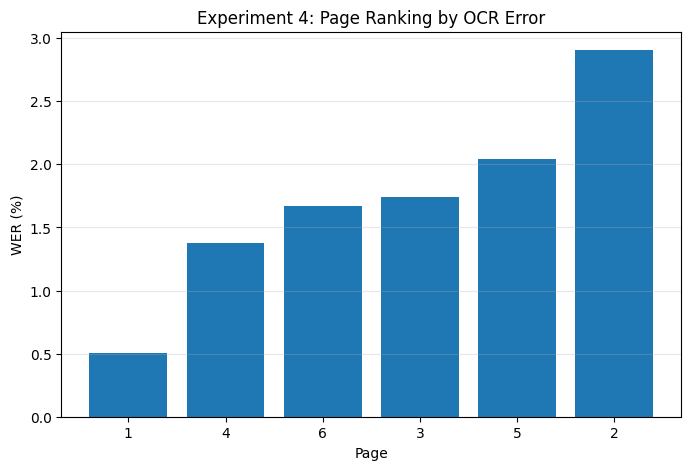

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["page"].astype(str),
    ranking_df["WER"] * 100
)

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("Experiment 4: Page Ranking by OCR Error")

plt.grid(axis="y", alpha=0.3)

plt.show()